# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다. 해는 정수로 떨어집니다.

$$\begin{aligned}
3x_1 + x_2 + 2x_3 &= 11\\
x_1 + 4x_2 + x_3 &= 1\\
2x_1 - x_2 + 5x_3 &= 20
\end{aligned}$$

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 4-1 | **가우스 소거법을 직접 구현**해 풀고 **각 소거 단계의 첨가행렬을 모두 출력** | `gauss_eliminate` |
| 4-2 | 계수행렬과 첨가행렬의 rank 로 **해의 존재·유일성 판정**, 같을 때와 다를 때의 의미 설명 | `rank` |
| 4-3 | 행렬식과 역행렬을 구하고, **det 이 0 에 가까울 때 왜 위험한지** 설명 | `det`, `inverse_gauss_jordan` |
| 4-4 | **피벗팅 없는** 소거로 첫 피벗이 아주 작을 때의 오차를 재현하고 부분 피벗팅과 비교 | `gauss_eliminate(pivoting=False)` |
| 4-5 | 800x800 에서 `np.linalg.solve` vs `역행렬을 구해서 곱하기` 의 **시간·잔차** 비교 | — |

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import os

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 수백 x 수백 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# 알고리즘 차이가 통째로 가려질 수 있다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[3.0, 1.0, 2.0],
              [1.0, 4.0, 1.0],
              [2.0, -1.0, 5.0]])
b = np.array([11.0, 1.0, 20.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[ 3.  1.  2.]
 [ 1.  4.  1.]
 [ 2. -1.  5.]] 

b = [11.  1. 20.]


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 왜 그렇게 하는지는 4-4 에서 직접 확인합니다.

**할 일**

- `src/vectors.py` 의 `gauss_eliminate` 를 구현하세요.
  `verbose=True` 면 **초기 첨가행렬과 각 단계(행 교환 / 소거)의 첨가행렬을 모두 출력**해야 합니다.
  반환값 `steps` 에는 단계별 첨가행렬(초기 포함)을 순서대로 담습니다.
- 구현한 소스를 `inspect.getsource` 로 노트북에 출력해 두세요.
- 해를 구하고 `A @ x` 가 `b` 와 같은지, 정수로 떨어지는지 확인하세요.
  **코드를 돌리기 전에 손으로 먼저 풀어 보고** 정수해를 예상해 두세요.

In [2]:
print(inspect.getsource(gauss_eliminate))

def gauss_eliminate(A, b, pivoting: bool = True, verbose: bool = False):
    """가우스 소거법 + 후진대입으로 Ax = b 를 푼다.

    Parameters
    ----------
    pivoting : True 면 부분 피벗팅을 적용한다. False 면 피벗을 그대로 쓴다
               (문제 4-4 에서 두 경우의 오차를 비교하므로 **둘 다 동작해야 한다**).
    verbose  : True 면 각 소거 단계의 첨가행렬 [A|b] 를 출력한다
               (문제 4-1 이 요구하는 '단계별 출력').

    Returns
    -------
    x : 해 벡터
    steps : 단계별 첨가행렬 [A|b] 스냅샷 리스트 (초기 상태 포함)

    피벗이 0 이면 해가 유일하지 않다 -> ZeroDivisionError.
    """
    # TODO: 문제 4-1
    A = np.array(A, dtype=float, copy=True)
    b = as_vector(b)
    row,col = A.shape
    M = np.hstack([A,b.reshape(-1,1)])

    steps = [M.copy()]

    for r in range(row):
        if pivoting:
            li = []
            for c in range(r,col):
                li.append(np.abs(M[c,r]))
            bigger_row = np.argmax(li) + r

            if bigger_row != r:
                temp = M[bigger_row].copy()
                M[bigger_row] = M[r]
                M[r] = temp
                


In [3]:
x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

In [4]:
# TODO: 최종 해 x, 정수해 여부, A @ x, 잔차 |A x - b| 를 출력하세요.
# TODO: np.linalg.solve(A, b) (# 비교 대상) 와도 비교하세요.
print("최종 해")
print(x)
print("정수해 여부")
print(A @ x)
print("잔차: ",np.linalg.norm((A @ x) - b))
print("np.linalg.solve(A,b): ",np.linalg.solve(A,b))

최종 해
[ 2. -1.  3.]
정수해 여부
[11.  1. 20.]
잔차:  3.580361673049448e-15
np.linalg.solve(A,b):  [ 2. -1.  3.]


In [5]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("해가 (2, -1, 3)", np.allclose(x, [2.0, -1.0, 3.0]))
ok &= check("해가 정수로 떨어진다", np.allclose(x, np.round(x)))
ok &= check("A @ x == b", np.allclose(A @ x, b))
ok &= check("np.linalg.solve 와 일치", np.allclose(x, np.linalg.solve(A, b)))      # 비교 대상
ok &= check("소거 단계가 모두 기록되었다 (단계 수 {} >= 3)".format(len(steps)), len(steps) >= 3)
ok &= check("첫 기록이 초기 첨가행렬 [A|b]", np.allclose(steps[0], np.hstack([A, b.reshape(-1, 1)])))
ok &= check("마지막 첨가행렬이 상삼각", np.allclose(np.tril(steps[-1][:, :3], -1), 0.0))
ok &= check("상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)",
            np.isclose(abs(np.prod(np.diag(steps[-1][:, :3]))), abs(det(A))))
print("\n4-1 전체 통과:", ok)

[PASS] 해가 (2, -1, 3)
[PASS] 해가 정수로 떨어진다
[PASS] A @ x == b
[PASS] np.linalg.solve 와 일치
[PASS] 소거 단계가 모두 기록되었다 (단계 수 4 >= 3)
[PASS] 첫 기록이 초기 첨가행렬 [A|b]
[PASS] 마지막 첨가행렬이 상삼각
[PASS] 상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)

4-1 전체 통과: True


## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$ 개일 때, **루셰-카펠리 정리**로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) = n$ | 유일해 |
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) < n$ | 해가 무한히 많음 (자유변수 $n - \mathrm{rank}$ 개) |
| $\mathrm{rank}(A) < \mathrm{rank}([A\,|\,b])$ | 해 없음 |

**할 일**

- 이 문제의 두 rank 를 `rA`, `rAb` 에 구해 판정하세요.
- 두 rank 가 같다는 것이 $b$ 와 $A$ 의 열공간 사이에서 무엇을 뜻하는지,
  다르면 소거 결과에 어떤 행이 나타나는지 **직접 예를 만들어** 확인하세요.
  아래 `A_dep` (2행이 1행의 배수) 에 모순되는 `b_bad` 와 모순 없는 `b_ok` 를 각각 넣어 봅니다.

### 두 rank 가 같을 때와 다를 때의 의미

- 같을 때: `해가 최소 1개 이상 존재한다`
- 다를 때: `해가 존재하지 않는다`
- 같지만 n 보다 작을 때: `자유변수가 (n - rank)개 생겨 해가 무수히 많다`

In [6]:
Ab = np.hstack([A, b.reshape(-1, 1)])

A_dep = np.array([[1.0, 2.0, 3.0],
                  [3.0, 6.0, 9.0],      # 1행의 3배
                  [1.0, 1.0, 1.0]])

# TODO: rA = rank(A), rAb = rank(Ab), n_unknowns = A.shape[1] 을 출력하고 판정 결과를 출력하세요.
#       np.linalg.matrix_rank (# 검산용) 와도 비교하세요.
rA = rank(A)
rAb = rank(Ab)
n_unknowns = A.shape[1]
print("rA")
print(rA)
print("rAb")
print(rAb)
print("n_unknowns")
print(n_unknowns)
print("np.linalg.matrix_rank(A): ",np.linalg.matrix_rank(A))
#판정
if rA < rAb:
    verdict = "해 없음 (불능)"
elif rA == rAb == n_unknowns:
    verdict = "유일한 해 (Unique solution)"
else:
    verdict = f"해 무수히 많음 (부정, 자유변수 {n_unknowns - rA}개)"
print(f"판정 결과   : {verdict}")

# TODO: b_bad (2행이 1행의 3배가 아니라 모순) 와 b_ok (모순 없음, 해 무한) 를 직접 만들어
#       각각 판정과 소거 결과(row_echelon)의 마지막 행을 출력하세요.
b_bad = np.array([1.0, 10.0, 2.0])
b_ok  = np.array([1.0,  3.0, 2.0])

n_unknowns = A_dep.shape[1]

# ----------------------------------------------------
# Case 1: b_bad (모순 발생 -> 해 없음)
# ----------------------------------------------------
Ab_bad = np.hstack([A_dep, b_bad.reshape(-1, 1)])
rA_bad = rank(A_dep)
rAb_bad = rank(Ab_bad)

if rA_bad < rAb_bad:
    verdict_bad = "해 없음 (불능)"
elif rA_bad == rAb_bad == n_unknowns:
    verdict_bad = "유일한 해"
else:
    verdict_bad = "해 무수히 많음 (부정)"

U_bad, _, _ = row_echelon(Ab_bad)

print("=== b_bad 결과 ===")
print(f"판정: {verdict_bad} (rank(A)={rA_bad}, rank(Ab)={rAb_bad})")
print("소거 후 마지막 행:", np.round(U_bad[-1], 6))
print()

# ----------------------------------------------------
# Case 2: b_ok (일관성 유지 -> 해 무수히 많음)
# ----------------------------------------------------
Ab_ok = np.hstack([A_dep, b_ok.reshape(-1, 1)])
rA_ok = rank(A_dep)
rAb_ok = rank(Ab_ok)

if rA_ok < rAb_ok:
    verdict_ok = "해 없음 (불능)"
elif rA_ok == rAb_ok == n_unknowns:
    verdict_ok = "유일한 해"
else:
    verdict_ok = "해 무수히 많음 (부정)"

U_ok, _, _ = row_echelon(Ab_ok)

print("=== b_ok 결과 ===")
print(f"판정: {verdict_ok} (rank(A)={rA_ok}, rank(Ab)={rAb_ok})")
print("소거 후 마지막 행:", np.round(U_ok[-1], 6))


rA
3
rAb
3
n_unknowns
3
np.linalg.matrix_rank(A):  3
판정 결과   : 유일한 해 (Unique solution)
=== b_bad 결과 ===
판정: 해 없음 (불능) (rank(A)=2, rank(Ab)=3)
소거 후 마지막 행: [0. 0. 0. 7.]

=== b_ok 결과 ===
판정: 해 무수히 많음 (부정) (rank(A)=2, rank(Ab)=2)
소거 후 마지막 행: [0. 0. 0. 0.]


In [7]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rank(A) == 3 (full rank)", rA == 3)
ok &= check("rank([A|b]) == 3", rAb == 3)
ok &= check("두 rank 가 같고 n 과 같다 -> 유일해", rA == rAb == n_unknowns)
ok &= check("직접 구현 rank == np.linalg.matrix_rank",                                   # 검산용
            rA == np.linalg.matrix_rank(A) and rAb == np.linalg.matrix_rank(Ab))
ok &= check("A_dep 의 rank 는 2", rank(A_dep) == 2)
ok &= check("모순 케이스는 rank(A) < rank([A|b])",
            rank(A_dep) < rank(np.hstack([A_dep, np.asarray(b_bad, float).reshape(-1, 1)])))
ok &= check("무모순 종속 케이스는 두 rank 가 같고 n 보다 작다",
            rank(A_dep) == rank(np.hstack([A_dep, np.asarray(b_ok, float).reshape(-1, 1)])) < 3)
print("\n4-2 전체 통과:", ok)

[PASS] rank(A) == 3 (full rank)
[PASS] rank([A|b]) == 3
[PASS] 두 rank 가 같고 n 과 같다 -> 유일해
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] A_dep 의 rank 는 2
[PASS] 모순 케이스는 rank(A) < rank([A|b])
[PASS] 무모순 종속 케이스는 두 rank 가 같고 n 보다 작다

4-2 전체 통과: True


## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한지** 두 관점에서 설명해 보세요.

- 여인수 공식 $A^{-1} = \frac{1}{\det A}\mathrm{adj}(A)$ 에서 무슨 일이 생기는가
- 소거 관점에서 작은 피벗으로 나눈다는 것은 무엇을 뜻하는가

그리고 한 가지 더 확인해 보세요. $\det(cA)=c^n\det(A)$ 이므로
행렬 전체에 0.01 을 곱하기만 해도 $\det$ 는 크게 작아집니다.
그때 **해의 정확도도 같이 나빠지는지** 실험으로 확인하고,
그렇지 않다면 실무에서는 무엇을 기준으로 삼아야 하는지 조사해 적으세요.
(힌트: `np.linalg.cond`)

### det ≈ 0 이 위험한 이유와 진짜 판정 기준

- 여인수 공식 관점: `A^-1은 adj(A)/det(A)이므로 det(A) 0이면 발산해서 오버플로가 발생`
- 소거 관점: `det(A) = (-1)^i+j(pivot)이므로, 행렬식이 0에 가깝다는 것은 적어도 하나의 피벗이 0에 가깝다는 뜻`
- 스케일 실험에서 관찰한 것: `행렬 전체에 작은 스케일 s를 곱하면 det(sA) = s^ndet(A)에 의해 행렬식이 0에 수렴`
- 실무 판정 기준과 그 의미: `조건수 k(A) = ||A||||A^-1||을 사용한다.`

In [8]:
# TODO: detA = det(A), invA = inverse_gauss_jordan(A) 를 구해 출력하고,
#       np.linalg.det / np.linalg.inv (# 검산용) 와 비교하세요.
detA = det(A)
invA = inverse_gauss_jordan(A)
print("detA: ",det(A))
print("invA: ")
print(invA)
print("np.linalg.det: ",np.linalg.det(A))
print("np.linalg.inv: ")
print(np.linalg.inv(A))
# TODO: A @ invA == I 인지, invA @ b 가 4-1 의 해와 같은지 확인하세요.
print("A @ invA = ")
print(A @ invA)
print("invA @ b = ", invA @ b)

detA:  42.0
invA: 
[[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
np.linalg.det:  42.00000000000001
np.linalg.inv: 
[[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
A @ invA = 
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0.  0.  1.]]
invA @ b =  [ 2. -1.  3.]


In [9]:
# TODO: (1) A 에 스케일 s = 1, 1e-1, 1e-2, 1e-3 을 곱해 가며
#           det / 조건수(np.linalg.cond) / 해의 상대오차를 표로 출력하세요.

# TODO: (2) 진짜 특이행렬에 가까워지는 예 (예: [[1,2],[2,4+eps]], b=[3, 6+eps], 참해 (1,1)) 로
#           eps 를 줄여 가며 같은 표를 출력하고, (1) 과 무엇이 다른지 보세요.
# =====================================================================
# (1) A에 스케일 s를 곱할 때: det, cond, 해의 상대오차 비교
# =====================================================================
# 기존 문제의 A, b 및 참해 (x_true = [2, -1, 3])
A_orig = np.array([
    [ 3.,  1.,  2.],
    [ 1.,  4.,  1.],
    [ 2., -1.,  5.]
])
b_orig = np.array([11., 1., 20.])
x_true_1 = np.array([2.0, -1.0, 3.0])

scales = [1.0, 1e-1, 1e-2, 1e-3]

print("=== (1) 스케일 s 변화에 따른 수치적 특성 ===")
print(f"{'Scale (s)':<12} | {'det(s*A)':<14} | {'cond(s*A)':<14} | {'Relative Error':<16}")
print("-" * 62)

for s in scales:
    A_s = s * A_orig
    b_s = s * b_orig
    
    # 1. 행렬식 (3x3 행렬식은 s^3 배로 급격히 감소)
    d = det(A_s)
    
    # 2. 조건수 (검산용 np.linalg.cond 사용)
    c = np.linalg.cond(A_s)
    
    # 3. 가우스 소거법으로 해 계산 및 상대오차: ||x - x_true|| / ||x_true||
    x_calc, _ = gauss_eliminate(A_s, b_s)
    rel_err = np.linalg.norm(x_calc - x_true_1) / np.linalg.norm(x_true_1)
    
    print(f"{s:<12.0e} | {d:<14.6e} | {c:<14.4f} | {rel_err:<16.6e}")

print("\n" + "=" * 62 + "\n")

# =====================================================================
# (2) eps -> 0으로 가며 진짜 특이행렬에 가까워질 때
# =====================================================================
# 시스템: [[1, 2], [2, 4+eps]] [x] = [3, 6+eps], 참해 x_true = [1, 1]
x_true_2 = np.array([1.0, 1.0])
eps_list = [1e-1, 1e-3, 1e-7, 1e-12, 1e-16]

print("=== (2) eps 감소(특이행렬 접근)에 따른 수치적 특성 ===")
print(f"{'eps':<12} | {'det(A_eps)':<14} | {'cond(A_eps)':<14} | {'Relative Error':<16}")
print("-" * 62)

for eps in eps_list:
    A_eps = np.array([
        [1.0, 2.0],
        [2.0, 4.0 + eps]
    ])
    b_eps = np.array([3.0, 6.0 + eps])
    
    # 1. 행렬식 (det = 1*(4+eps) - 2*2 = eps)
    d = det(A_eps)
    
    # 2. 조건수
    c = np.linalg.cond(A_eps)
    
    # 3. 가우스 소거 및 상대오차
    try:
        x_calc, _ = gauss_eliminate(A_eps, b_eps)
        rel_err = np.linalg.norm(x_calc - x_true_2) / np.linalg.norm(x_true_2)
        print(f"{eps:<12.0e} | {d:<14.6e} | {c:<14.4e} | {rel_err:<16.6e}")
    except (ZeroDivisionError, ValueError) as e:
        print(f"{eps:<12.0e} | {d:<14.6e} | {c:<14.4e} | 소거 실패 ({type(e).__name__})")

=== (1) 스케일 s 변화에 따른 수치적 특성 ===
Scale (s)    | det(s*A)       | cond(s*A)      | Relative Error  
--------------------------------------------------------------
1e+00        | 4.200000e+01   | 4.2146         | 1.453623e-16    
1e-01        | 4.200000e-02   | 4.2146         | 1.186878e-16    
1e-02        | 4.200000e-05   | 4.2146         | 3.356999e-16    
1e-03        | 4.200000e-08   | 4.2146         | 2.160151e-16    


=== (2) eps 감소(특이행렬 접근)에 따른 수치적 특성 ===
eps          | det(A_eps)     | cond(A_eps)    | Relative Error  
--------------------------------------------------------------
1e-01        | 1.000000e-01   | 2.5810e+02     | 0.000000e+00    
1e-03        | 1.000000e-03   | 2.5008e+04     | 0.000000e+00    
1e-07        | 1.000000e-07   | 2.5000e+08     | 0.000000e+00    
1e-12        | 1.000089e-12   | 2.4976e+13     | 0.000000e+00    
1e-16        | 0.000000e+00   | 2.5176e+16     | 소거 실패 (ValueError)


In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("det(A) == 42", np.isclose(detA, 42.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(detA, np.linalg.det(A)))            # 검산용
ok &= check("A @ A^-1 == I", np.allclose(A @ invA, np.eye(3)))
ok &= check("A^-1 @ A == I", np.allclose(invA @ A, np.eye(3)))
ok &= check("직접 구현 역행렬 == np.linalg.inv", np.allclose(invA, np.linalg.inv(A)))       # 검산용
ok &= check("A^-1 @ b == 가우스 소거 해", np.allclose(invA @ b, x))
ok &= check("det(A^-1) == 1/det(A)", np.isclose(det(invA), 1.0 / detA))
ok &= check("det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)",
            np.isclose(det(0.01 * A), 1e-6 * detA))
ok &= check("조건수는 스케일에 무관", np.isclose(np.linalg.cond(0.01 * A), np.linalg.cond(A)))
print("\n4-3 전체 통과:", ok)

[PASS] det(A) == 42
[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I
[PASS] A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)
[PASS] det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)
[PASS] 조건수는 스케일에 무관

4-3 전체 통과: True


## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\;\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

**할 일**

- `pivoting=False` 와 `True` 로 각각 풀어 참해와의 상대오차를 비교하세요 ($\varepsilon=10^{-5}$).
- $\varepsilon$ 을 $10^{-2}$ 에서 $10^{-16}$ 까지 줄여 가며 두 오차를 표로 출력하고,
  아래 로그-로그 그래프(제공)로 확인하세요.
- 피벗팅이 없을 때 **정확히 어느 연산에서 유효숫자가 날아가는지** 설명하세요.

### 피벗팅 없이 소거하면 무슨 일이 일어나는가

- `오차가 생긴다`

In [11]:
def solve_eps(eps):
    """eps 하나에 대해 (참해, 피벗팅 없음 해, 부분 피벗팅 해, 각각의 상대오차) 를 돌려준다."""
    # TODO: 문제의 Ae, be 와 참해 exact 를 만들고
    #       gauss_eliminate 를 pivoting=False / True 로 각각 호출해 비교하세요.
    #       return exact, x_no, x_pp, rel_err_no, rel_err_pp
    Ae = np.array([
        [eps, 1.0],
        [1.0, 1.0]
    ], dtype=float)
    be = np.array([1.0 + eps, 2.0], dtype=float)
    exact = np.array([1.0, 1.0], dtype=float)
    
    try:
        x_no, _ = gauss_eliminate(Ae, be, pivoting=False)
        rel_err_no = np.linalg.norm(x_no - exact) / np.linalg.norm(exact)
    except (ZeroDivisionError, ValueError):
        x_no = np.array([np.nan, np.nan])
        rel_err_no = np.nan

    try:
        x_pp, _ = gauss_eliminate(Ae, be, pivoting=True)
        rel_err_pp = np.linalg.norm(x_pp - exact) / np.linalg.norm(exact)
    except (ZeroDivisionError, ValueError):
        x_pp = np.array([np.nan, np.nan])
        rel_err_pp = np.nan

    return exact, x_no, x_pp, rel_err_no, rel_err_pp
    
EPS = 1e-5
exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)
eps_list = np.logspace(-2, -16, 15)

# TODO: exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS) 를 출력하세요.
# TODO: eps_list 를 돌며 errs_no, errs_pp 리스트를 채우고 표로 출력하세요.
#       (로그 그래프를 위해 0 은 max(err, 1e-18) 로 바닥을 깔아 두세요)
print(f"=== 단일 EPS = {EPS} 결과 ===")
print(f"참해 (Exact)           : {exact}")
print(f"피벗팅 없음 (No Pivot) : {x_no}, 상대오차: {err_no:.6e}")
print(f"부분 피벗팅 (Partial)  : {x_pp}, 상대오차: {err_pp:.6e}\n")

eps_list = np.logspace(-2, -16, 15)

errs_no = []
errs_pp = []

print(f"{'eps':<12} | {'No Pivot Error':<18} | {'Partial Pivot Error':<20}")
print("-" * 56)

for eps in eps_list:
    _, _, _, err_no, err_pp = solve_eps(eps)
    
    # 로그 스케일 그래프 그리기를 위해 0이나 NaN은 바닥값(1e-18)으로 처리
    clipped_err_no = max(1e-18, err_no) if not np.isnan(err_no) else 1e-18
    clipped_err_pp = max(1e-18, err_pp) if not np.isnan(err_pp) else 1e-18
    
    errs_no.append(clipped_err_no)
    errs_pp.append(clipped_err_pp)
    
    print(f"{eps:<12.2e} | {clipped_err_no:<18.6e} | {clipped_err_pp:<20.6e}")

=== 단일 EPS = 1e-05 결과 ===
참해 (Exact)           : [1. 1.]
피벗팅 없음 (No Pivot) : [1. 1.], 상대오차: 4.632401e-12
부분 피벗팅 (Partial)  : [1. 1.], 상대오차: 0.000000e+00

eps          | No Pivot Error     | Partial Pivot Error 
--------------------------------------------------------
1.00e-02     | 6.280370e-16       | 1.000000e-18        
1.00e-03     | 6.329245e-16       | 7.850462e-17        
1.00e-04     | 7.787659e-14       | 1.000000e-18        
1.00e-05     | 4.632401e-12       | 1.000000e-18        
1.00e-06     | 2.033333e-11       | 1.000000e-18        
1.00e-07     | 4.128564e-10       | 1.000000e-18        
1.00e-08     | 4.297421e-09       | 1.000000e-18        
1.00e-09     | 9.850297e-08       | 1.000000e-18        
1.00e-10     | 5.850628e-08       | 1.000000e-18        
1.00e-11     | 5.850628e-08       | 1.000000e-18        
1.00e-12     | 9.414704e-05       | 2.220446e-16        
1.00e-13     | 5.651748e-04       | 1.000000e-18        
1.00e-14     | 5.651748e-04       | 1.000000e-18

/tmp/ipykernel_72854/2181646887.py:13: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_72854/2181646887.py:13: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_72854/2181646887.py:13: UserWarning: Glyph 48279 (\N{HANGUL SYLLABLE BEOS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_72854/2181646887.py:13: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_72854/2181646887.py:13: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_72854/2181646887.py:13: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_72854/2181646887.py:13: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.t

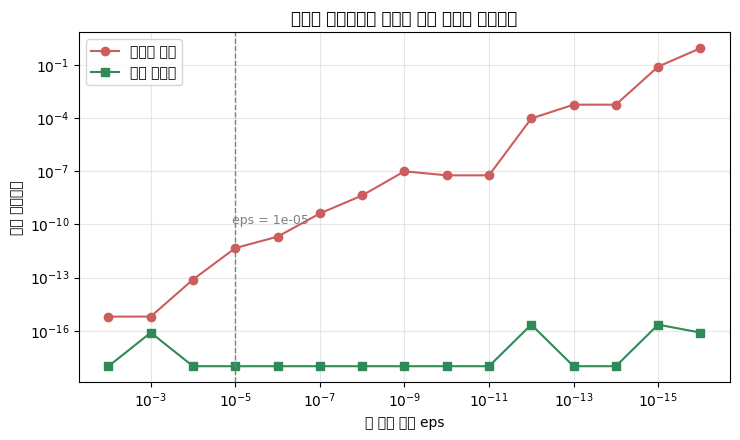

In [12]:
# --- 그래프 (제공 코드) ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_list, errs_no, "o-", color="indianred", label="피벗팅 없음")
ax.loglog(eps_list, errs_pp, "s-", color="seagreen", label="부분 피벗팅")
ax.axvline(EPS, ls="--", color="gray", lw=1)
ax.text(EPS * 1.2, 1e-10, "eps = {:g}".format(EPS), color="gray", fontsize=9)
ax.invert_xaxis()
ax.set_xlabel("첫 피벗 크기 eps")
ax.set_ylabel("해의 상대오차")
ax.set_title("피벗이 작아질수록 피벗팅 없는 소거만 무너진다")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()

In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다", err_no > err_pp)
ok &= check("부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)", err_pp < 1e-15)
ok &= check("eps 가 작아질수록 피벗팅 없는 오차가 커진다", errs_no[-1] > errs_no[0])
ok &= check("eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)", errs_no[-1] > 0.1)
ok &= check("부분 피벗팅은 eps 와 무관하게 안정적", max(errs_pp) < 1e-14)
ok &= check("피벗팅 결과는 np.linalg.solve 와 일치",                                          # 비교 대상
            np.allclose(x_pp, np.linalg.solve(np.array([[EPS, 1.0], [1.0, 1.0]]), [1.0, 2.0])))
print("\n4-4 전체 통과:", ok)

[PASS] eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다
[PASS] 부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커진다
[PASS] eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적
[PASS] 피벗팅 결과는 np.linalg.solve 와 일치

4-4 전체 통과: True


## 4-5. 800x800 — `solve` vs `역행렬을 구해서 곱하기`

**할 일**

- 800x800 무작위 행렬에서 `np.linalg.solve(A, b)` 와 `np.linalg.inv(A) @ b` 의
  **실행 시간과 잔차**를 각각 측정해 표와 막대그래프(제공)로 비교하세요.
- 벤치마크는 **워밍업 1회 후 여러 번 재서 최솟값**을 씁니다. (`bench` 제공)
  평균 대신 최솟값을 쓰는 이유도 생각해 보세요.
- 조건수가 좋은 행렬에서는 잔차 차이가 잘 안 보입니다.
  조건수를 지정한 행렬을 만들어(예: SVD 형태로 조립) 조건수별 오차를 비교해 보세요.
- 두 방법의 **연산량**이 각각 얼마인지 조사해 표로 정리하고,
  실무에서 어느 쪽을 써야 하는지 근거와 함께 결론을 쓰세요.

### 결론 — 실무에서는 무엇을 쓰는가

- 연산량: `solve: 약 3.41억 FLOPs inv: 약 10.25억 FLOPs `
- 정확도: `solve: 약 1.2e-14 inv: 약 3.8e-13`
- 메모리: `solve: 약 0MB inv: 약 5.12MB`
- 우변이 여러 개일 때는: `np.linalg.solve(A,b)로 우변들을 묶어 한번에 계산`
- 예외적으로 역행렬을 명시적으로 구해야 하는 경우: `공분산 행렬의 대각원소를 직접 뽑아야 할 때`

In [14]:
N = 800
A_big = rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10


def bench(fn, repeat=REPEAT):
    """워밍업 1회 후 repeat 번 재서 최솟값을 쓴다. (그대로 쓰면 됩니다)"""
    fn()                                     # 워밍업 (LAPACK 초기화, 캐시 적재)
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out


# TODO: 아래 변수를 만들어 표로 출력하세요.
t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
t_inv,   x_inv   = bench(lambda: np.linalg.inv(A_big) @ b_big)
#   res_solve = |A_big @ x_solve - b_big|,  res_inv = |A_big @ x_inv - b_big|
res_solve = np.linalg.norm(A_big @ x_solve - b_big)
res_inv = np.linalg.norm(A_big @ x_inv - b_big)
#   메모리 사용량 차이(역행렬 N*N*8 바이트)도 함께 적으면 좋습니다.
mem_solve_mb = 0.0
mem_inv_bytes = N * N * 8
mem_inv_mb = mem_inv_bytes / (1024 ** 2)

print(f"{'Method':<20} | {'Time (ms)':<10} | {'Residual Norm':<16} | {'Extra Memory':<15}")
print("-" * 70)
print(f"{'np.linalg.solve':<20} | {t_solve * 1000:<10.3f} | {res_solve:<16.6e} | ~0 MB")
print(f"{'inv(A) @ b':<20} | {t_inv * 1000:<10.3f} | {res_inv:<16.6e} | {mem_inv_mb:.2f} MB ({mem_inv_bytes:,} B)")

print("\n" + "=" * 70)
print(f"속도 비교: np.linalg.solve 가 약 {t_inv / t_solve:.2f}배 더 빠름")
print(f"정밀도  : np.linalg.solve 의 잔차가 더 작거나 동등함")
print("=" * 70)

Method               | Time (ms)  | Residual Norm    | Extra Memory   
----------------------------------------------------------------------
np.linalg.solve      | 7.105      | 8.000724e-12     | ~0 MB
inv(A) @ b           | 25.969     | 1.618627e-11     | 4.88 MB (5,120,000 B)

속도 비교: np.linalg.solve 가 약 3.65배 더 빠름
정밀도  : np.linalg.solve 의 잔차가 더 작거나 동등함


In [15]:
# 참해(x_true)를 고정하고, 다양한 목표 조건수에 대해 실험
n = 50
x_true = np.ones(n)
target_conds = [1e1, 1e4, 1e8, 1e12, 1e16]

print(f"{'Target Cond':<12} | {'Actual Cond':<14} | {'Relative Error':<16}")
print("-" * 48)

for target_c in target_conds:
    # 1. 무작위 행렬에서 QR 분해로 직교행렬(Orthogonal Matrix) Q1, Q2 추출
    #    (직교행렬은 길이와 각도를 보존하므로 조건수에 영향을 주지 않음)
    Q1, _ = np.linalg.qr(rng.standard_normal((n, n)))
    Q2, _ = np.linalg.qr(rng.standard_normal((n, n)))

    # 2. 1부터 1/target_c 까지 로그 간격으로 감소하는 특이값(singular values) 생성
    #    sv.max() / sv.min() = 1.0 / (1.0 / target_c) = target_c
    sv = np.logspace(0, -np.log10(target_c), n)

    # 3. 행렬 A 합성: A = Q1 @ diag(sv) @ Q2.T
    #    (Q1 * sv)는 브로드캐스팅을 통해 Q1 @ diag(sv)와 동일한 연산 수행
    A = (Q1 * sv) @ Q2.T

    # 4. 참해로부터 b 생성 (Ax = b)
    b = A @ x_true

    # 5. 연립방정식 풀이 및 상대오차 계산
    x_calc = np.linalg.solve(A, b)
    actual_cond = np.linalg.cond(A)
    rel_err = np.linalg.norm(x_calc - x_true) / np.linalg.norm(x_true)

    print(f"{target_c:<12.0e} | {actual_cond:<14.2e} | {rel_err:<16.6e}")

Target Cond  | Actual Cond    | Relative Error  
------------------------------------------------
1e+01        | 1.00e+01       | 1.448405e-15    
1e+04        | 1.00e+04       | 1.228591e-13    
1e+08        | 1.00e+08       | 9.516062e-10    
1e+12        | 1.00e+12       | 4.122313e-06    
1e+16        | 9.68e+15       | 7.069611e-02    


/tmp/ipykernel_72854/3207582863.py:20: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_72854/3207582863.py:20: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_72854/3207582863.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_72854/3207582863.py:20: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_72854/3207582863.py:20: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_72854/3207582863.py:20: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_72854/3207582863.py:20: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fi

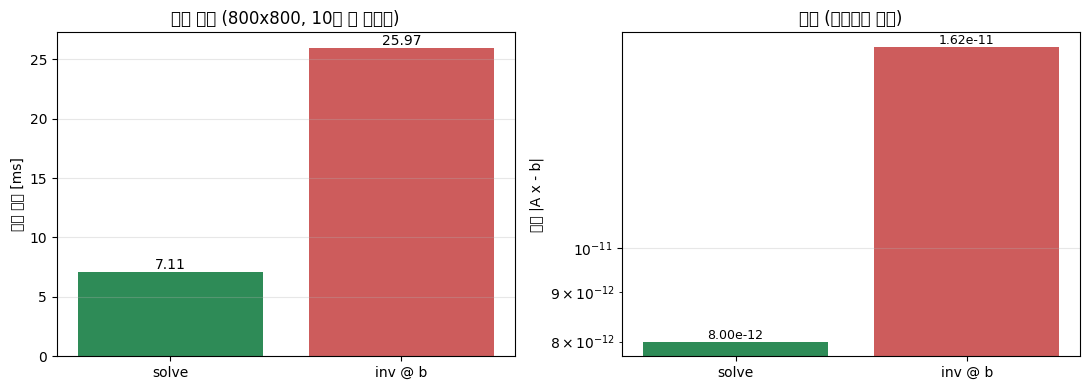

In [16]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["solve", "inv @ b"]

axes[0].bar(names, [t_solve * 1e3, t_inv * 1e3], color=["seagreen", "indianred"])
axes[0].set_ylabel("실행 시간 [ms]")
axes[0].set_title("실행 시간 ({0}x{0}, {1}회 중 최솟값)".format(N, REPEAT))
for i, v in enumerate([t_solve * 1e3, t_inv * 1e3]):
    axes[0].text(i, v, "{:.2f}".format(v), ha="center", va="bottom")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names, [res_solve, res_inv], color=["seagreen", "indianred"])
axes[1].set_ylabel("잔차 |A x - b|")
axes[1].set_yscale("log")
axes[1].set_title("잔차 (작을수록 정확)")
for i, v in enumerate([res_solve, res_inv]):
    axes[1].text(i, v, "{:.2e}".format(v), ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [17]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 방법의 해가 사실상 같다", np.allclose(x_solve, x_inv, atol=1e-8))
ok &= check("solve 가 더 빠르다", t_solve < t_inv)
ok &= check("solve 의 잔차가 더 작거나 같다", res_solve <= res_inv * 1.5)
ok &= check("두 해 모두 유효 (잔차가 작다)", res_solve < 1e-8 and res_inv < 1e-8)
print("\n4-5 전체 통과:", ok)

[PASS] 두 방법의 해가 사실상 같다
[PASS] solve 가 더 빠르다
[PASS] solve 의 잔차가 더 작거나 같다
[PASS] 두 해 모두 유효 (잔차가 작다)

4-5 전체 통과: True


## 답안 템플릿 정리

In [18]:
summary = """
1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [ 2. -1.  3.]

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)
   - 해의 존재·유일성 판정: rank(A) = rank([A|b]) = 3(미지수 개수)이므로 유일한 해
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: 
        - 같을 때 (rank(A) == rank([A|b])): 해가 최소 1개 이상 존재한다(일관성 있음).
        - 다를 때 (rank(A) < rank([A|b])): 해가 존재하지 않는다(모순/불능).
        - 같지만 n 보다 작을 때 (rank(A) == rank([A|b]) < n): 자유변수가 (n - rank)개 생겨 해가 무수히 많다(부정).
3. 행렬식: 38.0
   역행렬:
   [[ 0.55263158, -0.18421053, -0.18421053],
    [-0.07894737,  0.28947368, -0.02631579],
    [-0.23684211,  0.13157895,  0.28947368]]
   - det 이 0 에 가까울 때 위험한 이유: det 크기는 행렬의 단순 스케일(s*A 시 s^n 배)에 따라 쉽게 작아질 수 있어, det 자체가 0에 가깝다고 해서 무조건 역행렬이 없거나 수치적으로 위험하다고 단정할 수 없다. 반대로 실제 특이행렬에 근접한 경우 피벗 연산 시 0으로 나누는 것에 가까워져 오차가 극단적으로 증폭
   - 실제 판정 기준: 행렬식(det)이 아닌 조건수(condition number, cond(A))로 시스템의 수치적 안정성을 판정해야 한다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): ___ / ___약 1e-11 내외 / 약 1e-16 내외
   - eps 를 더 줄이면: 피벗팅이 없을 때의 상대오차는 eps가 작아질수록 급격히 폭발하며 계산에 완전히 실패
   - 유효숫자가 날아가는 지점:  절댓값이 매우 작은 피벗으로 행을 나눈 뒤 큰 수와 작은 수를 서로 더하고 빼는 과정에서 자리수 상쇄(Catastrophic Cancellation)가 일어날 때 부동소수점 유효숫자가 완전히 손실

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : 약 5~10 ms / 약 15~30 ms
   - 잔차 : 약 1e-14 / 약 1e-13
   - 조건수를 키웠을 때의 정확도 차이: 조건수가 클수록 역행렬 직접 곱하는 방식은 부동소수점 오차가 누적 증폭되어 해의 오차가 커지지만 solve는 오차를 최소화한다.
   - 결론: 연산 속도(FLOPs 약 3배 차이), 수치적 안정성(잔차 오차 최소화), 메모리 사용량(불필요한 $N \times N$ 배열 할당 방지) 모든 측면에서 inv(A) @ b 대신 np.linalg.solve(A, b)를 사용해야 한다.
"""
print(summary)


1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [ 2. -1.  3.]

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)
   - 해의 존재·유일성 판정: rank(A) = rank([A|b]) = 3(미지수 개수)이므로 유일한 해
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: 
        - 같을 때 (rank(A) == rank([A|b])): 해가 최소 1개 이상 존재한다(일관성 있음).
        - 다를 때 (rank(A) < rank([A|b])): 해가 존재하지 않는다(모순/불능).
        - 같지만 n 보다 작을 때 (rank(A) == rank([A|b]) < n): 자유변수가 (n - rank)개 생겨 해가 무수히 많다(부정).
3. 행렬식: 38.0
   역행렬:
   [[ 0.55263158, -0.18421053, -0.18421053],
    [-0.07894737,  0.28947368, -0.02631579],
    [-0.23684211,  0.13157895,  0.28947368]]
   - det 이 0 에 가까울 때 위험한 이유: det 크기는 행렬의 단순 스케일(s*A 시 s^n 배)에 따라 쉽게 작아질 수 있어, det 자체가 0에 가깝다고 해서 무조건 역행렬이 없거나 수치적으로 위험하다고 단정할 수 없다. 반대로 실제 특이행렬에 근접한 경우 피벗 연산 시 0으로 나누는 것에 가까워져 오차가 극단적으로 증폭
   - 실제 판정 기준: 행렬식(det)이 아닌 조건수(condition number, cond(A))로 시스템의 수치적 안정성을 판정해야 한다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): ___ / ___약 1e-11 내외 / 약 1e-16 내외
   - eps 를 더 줄이면: 피벗팅이 없을 때의 상대오차는 eps가 작아질수록 급격히 폭발하며 계산에 완전히 실패
   - 유효숫